In [12]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt



# Preliminary Setup

In [13]:
# Set the device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data loading and preprocessing

In [14]:
xdata = []
# Assuming the Excel file is in the same directory as the script
file_name = "Data/intensity_noise/Throat_data1_with_intensity_noise.xlsx"

# Read the Excel file
df = pd.read_excel(file_name, header=None).T

# Extract wavenumbers which we assume to be in the first column
wavenumbers = torch.tensor(df.iloc[7:335, 0].to_list())
#print(f"wavenumbers: {wavenumbers}")

for column in df.columns:
    if column == 0:
        continue
    intensities = torch.tensor(df.iloc[7:335, column].to_list())

    sample = torch.stack((intensities,wavenumbers), -1)
    xdata.append(sample)

xdata = torch.stack(xdata)
xdata = xdata.transpose(1, 2)  # Transpose to shape [96, 2, 328]


print(f"xdata shape: {xdata.shape}")
print(f"xdata[0] shape: {xdata[0].shape}")


# print(f"xdata[0]: {xdata[0]}")
# print(f"xdata[1]: {xdata[1]}")
# print(f"xdata[2]: {xdata[2]}")
# print(f"xdata[3]: {xdata[3]}")
# print(f"xdata[4]: {xdata[4]}")


xdata shape: torch.Size([333, 2, 328])
xdata[0] shape: torch.Size([2, 328])


In [15]:
# Convert list of matrices to dataset
dataset =  (xdata - xdata.mean()) / xdata.std()


# Split the dataset into training and validation sets (80-20 split here)
train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


# Print out the sizes to confirm
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")


Training dataset size: 266
Validation dataset size: 67


# Architecture

In [16]:

class ConvVAE(nn.Module):
    def __init__(self, in_channels=2, latent_dim=3):
        super(ConvVAE, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 8, kernel_size=3, stride=2, padding=1),  # Output: (8, 164)
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=3, stride=2, padding=1),  # Output: (16, 82)
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1),  # Output: (32, 41)
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1),  # Output: (64, 21)
            nn.ReLU(),
        )
        
        # Calculate the flattened feature size after all convolutions
        self.flattened_size = 64 * 21

        # Fully connected layers for learning the mean and log variance
        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_log_var = nn.Linear(self.flattened_size, latent_dim)
        
        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, self.flattened_size)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(8, in_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Upsample(size=328, mode='linear'),  # Ensures the output length matches the input
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encoder
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        
        # Reparameterization trick
        z = self.reparameterize(mu, log_var)
        
        # Decoder
        x = self.decoder_fc(z)
        x = x.view(x.size(0), 64, -1)
        x = self.decoder_conv(x)
        return x, mu, log_var



# Setup and Train

In [17]:
# Initialize the VAE model
model = ConvVAE().to(device)

# Create data loaders
batch_size = 1  # Adjust the batch size as needed
num_epochs = 500 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



Epoch 1, Train Loss: 439.6063, Test Loss: 424.5742
Epoch 51, Train Loss: 316.9564, Test Loss: 339.1004
Epoch 101, Train Loss: 315.5328, Test Loss: 339.2777
Epoch 151, Train Loss: 315.1016, Test Loss: 338.1205
Epoch 201, Train Loss: 315.3209, Test Loss: 337.8867
Epoch 251, Train Loss: 315.0927, Test Loss: 338.0374
Epoch 301, Train Loss: 315.3607, Test Loss: 338.2206
Epoch 351, Train Loss: 314.9617, Test Loss: 338.0595
Epoch 401, Train Loss: 315.1473, Test Loss: 338.0159
Epoch 451, Train Loss: 315.0745, Test Loss: 338.4487


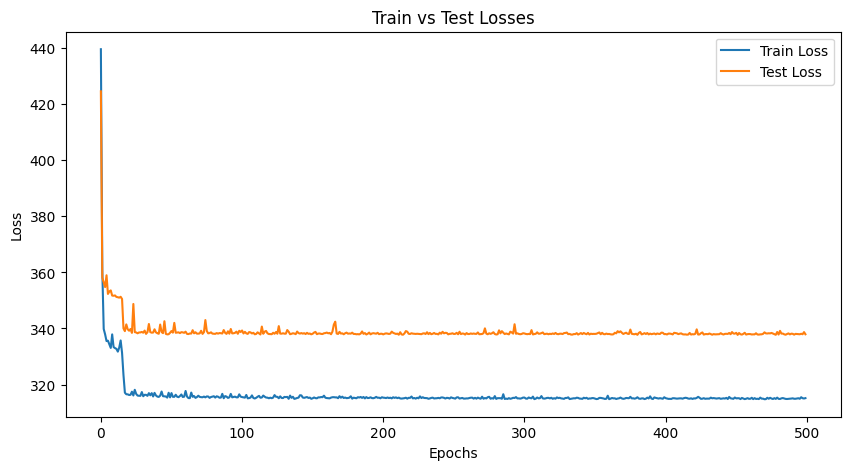

In [18]:

def train_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    for x in train_loader:
        x = x.to(device)  # Send data to the correct device
        optimizer.zero_grad()
        reconstructed, mu, log_var = model(x)

        # Check if the size of the reconstructed data matches the input
        if reconstructed.shape != x.shape:
            raise RuntimeError(f"Size mismatch: reconstructed shape {reconstructed.shape} vs input shape {x.shape}")

        # Calculate loss
        recon_loss = F.mse_loss(reconstructed, x, reduction='sum')
        kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        loss = recon_loss + kl_div

        # Backpropagation
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader.dataset)

def test_epoch(model, test_loader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x in test_loader:
            x = x.to(device)  # Send data to the correct device
            reconstructed, mu, log_var = model(x)

            # Calculate loss
            recon_loss = F.mse_loss(reconstructed, x, reduction='sum')
            kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            loss = recon_loss + kl_div
            total_loss += loss.item()
    return total_loss / len(test_loader.dataset)


# Initialize lists to keep track of losses
train_losses = []
test_losses = []

# Training loop
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    test_loss = test_epoch(model, test_loader, device)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    if(epoch % 50 == 0):
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

# Plotting the losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Test Losses')
plt.legend()
plt.show()


# Output

In [19]:

# Initialize the VAE with the correct input channel size
vae = ConvVAE(in_channels=2, latent_dim=3) 

# Set the VAE to evaluation mode and perform a forward pass to get the compressed representation
vae.eval()
with torch.no_grad():
    _, mu, _ = vae(dataset)
    new_compressed_data = mu.detach().cpu().numpy()  # Convert to numpy array

# Create labels (file names) for the new data
new_labels = [file_name] * new_compressed_data.shape[0]

# Combine the new compressed data and new labels
new_combined_data = pd.DataFrame(new_compressed_data)
new_combined_data['Label'] = new_labels

# Path to the existing Excel file
excel_file_path = "Data/Intensity_noise/compressed_data_with_intensity_noise.xlsx"

# Read the existing data
try:
    existing_data = pd.read_excel(excel_file_path)
except FileNotFoundError:
    existing_data = pd.DataFrame()  # If file doesn't exist, create an empty DataFrame

# Append the new data to the existing data
all_data = pd.concat([existing_data, new_combined_data], ignore_index=True)

# Save the combined data back to the Excel file
all_data.to_excel(excel_file_path, index=False)
